In [87]:
import numpy as np
import json
import torch
import torch.nn as nn
from pathlib import Path
from matplotlib import pyplot as plt

In [88]:
from src.utils.schedulers import WarmupInvRsqrtLR, WarmupCosineDecayLR, WarmupCosineAnnealingWarmRestarts
from src.models.model_utilizer import update_optimizer_simple

In [89]:
config_dir = Path("./src/config/")

model_config_path = config_dir / "base-model-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

In [90]:
scheduler_types = [
    'CosineAnnealingLR',
    'CosineAnnealingWarmRestarts',
    'WarmupCosineAnnealing',
    'WarmupCosineAnnealingWarmRestarts',
    'WarmupInvRsqrtLR',
    'WarmupCosineDecayLR'
]


In [91]:
optimizers = {}
schedulers = {}

for scheduler_type in scheduler_types:
    
    if scheduler_type == 'CosineAnnealingLR':
        optimizers['CosineAnnealingLR'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )

        schedulers['CosineAnnealingLR'] = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizers['CosineAnnealingLR'],
            T_max=model_config['scheduler_T_max'],
            eta_min=model_config['scheduler_eta_min']
            )

    elif scheduler_type == 'CosineAnnealingWarmRestarts':
        optimizers['CosineAnnealingWarmRestarts'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )
        
        schedulers['CosineAnnealingWarmRestarts'] = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizers['CosineAnnealingWarmRestarts'],
            T_0=model_config['scheduler_T_0'],
            T_mult=model_config['scheduler_T_mult'],
            eta_min=model_config['scheduler_eta_min']
        )
    
    elif scheduler_type == 'WarmupCosineAnnealing':
        optimizers['WarmupCosineAnnealing'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )
        
        schedulers['WarmupCosineAnnealing'] = WarmupCosineAnnealingWarmRestarts(
            optimizers['WarmupCosineAnnealing'],
            lr_max=model_config['base_lr'],
            warmup_steps=model_config['scheduler_warmup_steps'],
            T_0=model_config['scheduler_T_0'],
            T_mult=model_config['scheduler_T_mult'],
            eta_min=model_config['scheduler_eta_min'],
            restart_flag=False
        )
        
    elif scheduler_type == 'WarmupCosineAnnealingWarmRestarts':
        optimizers['WarmupCosineAnnealingWarmRestarts'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )
        
        schedulers['WarmupCosineAnnealingWarmRestarts'] = WarmupCosineAnnealingWarmRestarts(
            optimizers['WarmupCosineAnnealingWarmRestarts'],
            lr_max=model_config['base_lr'],
            warmup_steps=model_config['scheduler_warmup_steps'],
            T_0=model_config['scheduler_T_0'],
            T_mult=model_config['scheduler_T_mult'],
            eta_min=model_config['scheduler_eta_min'],
            restart_flag=True
        )

    elif scheduler_type == 'WarmupInvRsqrtLR':
        optimizers['WarmupInvRsqrtLR'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )
        
        schedulers['WarmupInvRsqrtLR'] = WarmupInvRsqrtLR(
            optimizers['WarmupInvRsqrtLR'],
            lr_max=model_config['base_lr'],
            warmup_steps=model_config['scheduler_warmup_steps']
        )

    elif scheduler_type == 'WarmupCosineDecayLR':
        optimizers['WarmupCosineDecayLR'] = update_optimizer_simple(
            net = nn.Linear(10, 10),
            optim = model_config['solver_type'],
            lr=model_config['base_lr'],
            decay=model_config['weight_decay']
        )
        
        schedulers['WarmupCosineDecayLR'] = WarmupCosineDecayLR(
            optimizers['WarmupCosineDecayLR'],
            lr_max=model_config['base_lr'],
            warmup_steps=model_config['scheduler_warmup_steps'],
            decay_rate=model_config['decay_rate'],
            eta_min=model_config['scheduler_eta_min']
        )
        
    else:
        raise NotImplementedError(f"Scheduler not supported: {scheduler_type}")

In [92]:
import warnings
warnings.filterwarnings("ignore", message=".*Detected call of `lr_scheduler.step\(\)` before `optimizer.step\(\)`.*")


batch_size = model_config['batch_size']
train_dataset_size = 36_000
batch_num = train_dataset_size // batch_size

if model_config['scheduler_mode'] == 'batch':
    total_steps = model_config['epochs'] * batch_num
elif model_config['scheduler_mode'] == 'epoch':
    total_steps = model_config['epochs']
else:
    raise NotImplementedError(f"Scheduler MODE not supported: {model_config['scheduler_mode']}")


histories = {}
for scheduler_name, scheduler_val in schedulers.items():
    lrs = []
    for _ in range(total_steps):
        lrs.append(scheduler_val.get_last_lr()[0])
        scheduler_val.step()
    histories[scheduler_name] = lrs

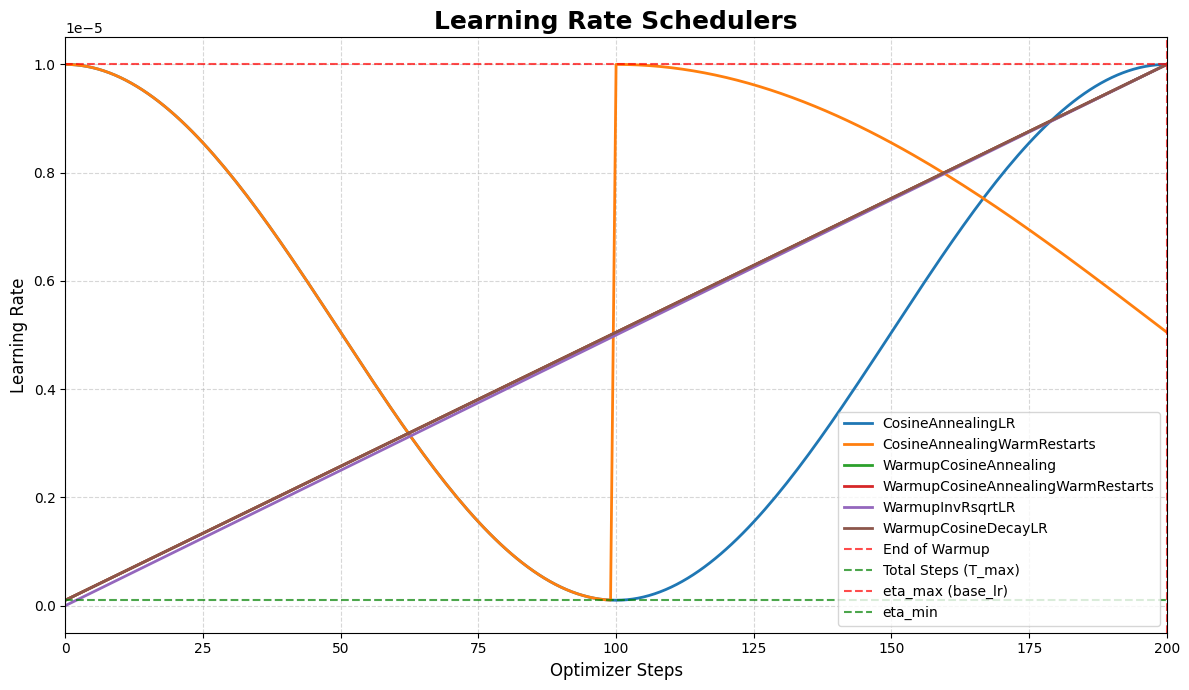

In [94]:
warmup_steps = model_config['scheduler_warmup_steps']

plt.figure(figsize=(12, 7))
for name, lrs in histories.items():
    #if name == 'CosineAnnealingLR':
    plt.plot(lrs, label=name, linewidth=2)
    
plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.7, label='End of Warmup')
plt.axvline(x=total_steps, color='g', linestyle='--', alpha=0.7, label='Total Steps (T_max)')

plt.axhline(y=model_config['base_lr'], color='r', linestyle='--', alpha=0.7, label='eta_max (base_lr)')
plt.axhline(y=model_config['scheduler_eta_min'], color='g', linestyle='--', alpha=0.7, label='eta_min')

plt.title("Learning Rate Schedulers", fontsize=18, fontweight='bold')
plt.xlabel("Optimizer Steps", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0*warmup_steps, 1*warmup_steps])
plt.tight_layout()
plt.show()